# SPX volatility surface — SVI & SSVI

Arbitrage-checked volatility surface on the pinned **2026-07-13** SPX snapshot.

- **Per-expiry raw SVI** — accurate fit, one smile per expiry (`engine/svi.py`)
- **Global SSVI** — one surface, *provably arbitrage-free by construction* (`engine/ssvi.py`)
- No-arb: butterfly `g(k) >= 0` (Gatheral-Jacquier) + calendar (total-variance monotonicity)
- Metrics: ATM term structure, 25-delta skew (`engine/metrics.py`)

In [12]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from engine import data, filters, surface, blackscholes as bs
from engine.svi import svi_w, svi_g, fit_surface
from engine.ssvi import ssvi_w, fit_ssvi, atm_theta
from engine.metrics import surface_metrics, butterfly_free_fraction, forward_vol

RATE, PINNED = 0.04, "2026-07-13"
CURVE, DOT, WARN, GREEN = "#2D5F8A", "#5A646E", "#AC4227", "#1F9E89"

def slice_iv(r, k):
    """Fitted IV(%) of one SVI slice at log-moneyness k."""
    return np.sqrt(np.maximum(svi_w(k, r.a, r.b, r.rho, r.m, r.sigma), 1e-9) / r["T"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Clean OTM quotes → k, w, weights

Same pipeline as `surface.ipynb`, via the shared `engine.surface.blend_roots` so the two
can't drift: two-sided + `T>0` filters, parity forward, OTM side, one root per expiry
(SPXW ≤60d, richest beyond — ADR 015), our own Newton–bisection IV. Then log-moneyness `k`,
total variance `w = iv²·T`, and `vega/spread` weights (tight/high-vega quotes count more).

In [13]:
df = data.chain_to_frame(data.load_chain(PINNED))
df = df[filters.bidask_mask(df) & filters.expiry_mask(df)].copy()
df["F"] = df["expiry"].map(surface.forward_by_expiry(df, RATE))
df = df[df["F"].notna()].copy()
df = df[surface.select_otm(df)].copy()

# one root per expiry: SPXW <=60d, richest beyond (surface.blend_roots, ADR 015).
# Shared with surface.ipynb so the two notebooks can't drift on this choice.
df = surface.blend_roots(df)

df["iv"] = bs.implied_vol(df["mid"], df["F"], df["strike"], df["T"], df["type"], RATE)
df = df[(df["iv"] > 0.01) & (df["iv"] < 3.0)].copy()
df["k"] = np.log(df["strike"] / df["F"])
df["w"] = df["iv"]**2 * df["T"]
vega = bs.bs_vega(df["F"], df["strike"], df["T"], df["iv"], RATE)
df["weights"] = vega / np.maximum(df["ask"] - df["bid"], 0.05)
df = df.sort_values(["T", "k"]).reset_index(drop=True)

print(f"{len(df):,} clean OTM quotes across {df.expiry.nunique()} expiries, "
      f"{df['T'].min()*365:.0f}-{df['T'].max()*365:.0f} days")

12,091 clean OTM quotes across 55 expiries, 1-1985 days


## Raw SVI per expiry

`fit_surface` runs the Zeliade quasi-explicit fit on each expiry, then `surface_metrics`
reads ATM vol and 25-delta skew off the fitted curves.

In [14]:
fit = atm_theta(fit_surface(df, weight_col="weights")).sort_values("T").reset_index(drop=True)
met = surface_metrics(fit)

n_fit = int(fit["a"].notna().sum())
print(f"fitted {n_fit}/{len(fit)} expiries (skipped {len(fit)-n_fit} thin), "
      f"median fit error {fit['rmse_vol'].median()*100:.3f} vol pts "
      f"(w-space rmse {fit['rmse'].median():.2e})")
met[["expiry", "T", "n_quotes", "atm_vol", "skew_25d", "fly_25d", "rmse_vol"]].head()

fitted 55/55 expiries (skipped 0 thin), median fit error 0.274 vol pts (w-space rmse 1.35e-04)


,expiry,T,n_quotes,atm_vol,skew_25d,fly_25d,rmse_vol
0,2026-07-14,0.002740,142,0.165770,0.030311,0.001496,0.007807
1,2026-07-15,0.005479,197,0.147921,0.023153,0.003075,0.010988
2,2026-07-16,0.008219,207,0.141803,NaN,NaN,0.009985
3,2026-07-17,0.010959,396,0.142305,NaN,NaN,0.006116
4,2026-07-20,0.019178,186,0.120888,NaN,NaN,0.005935


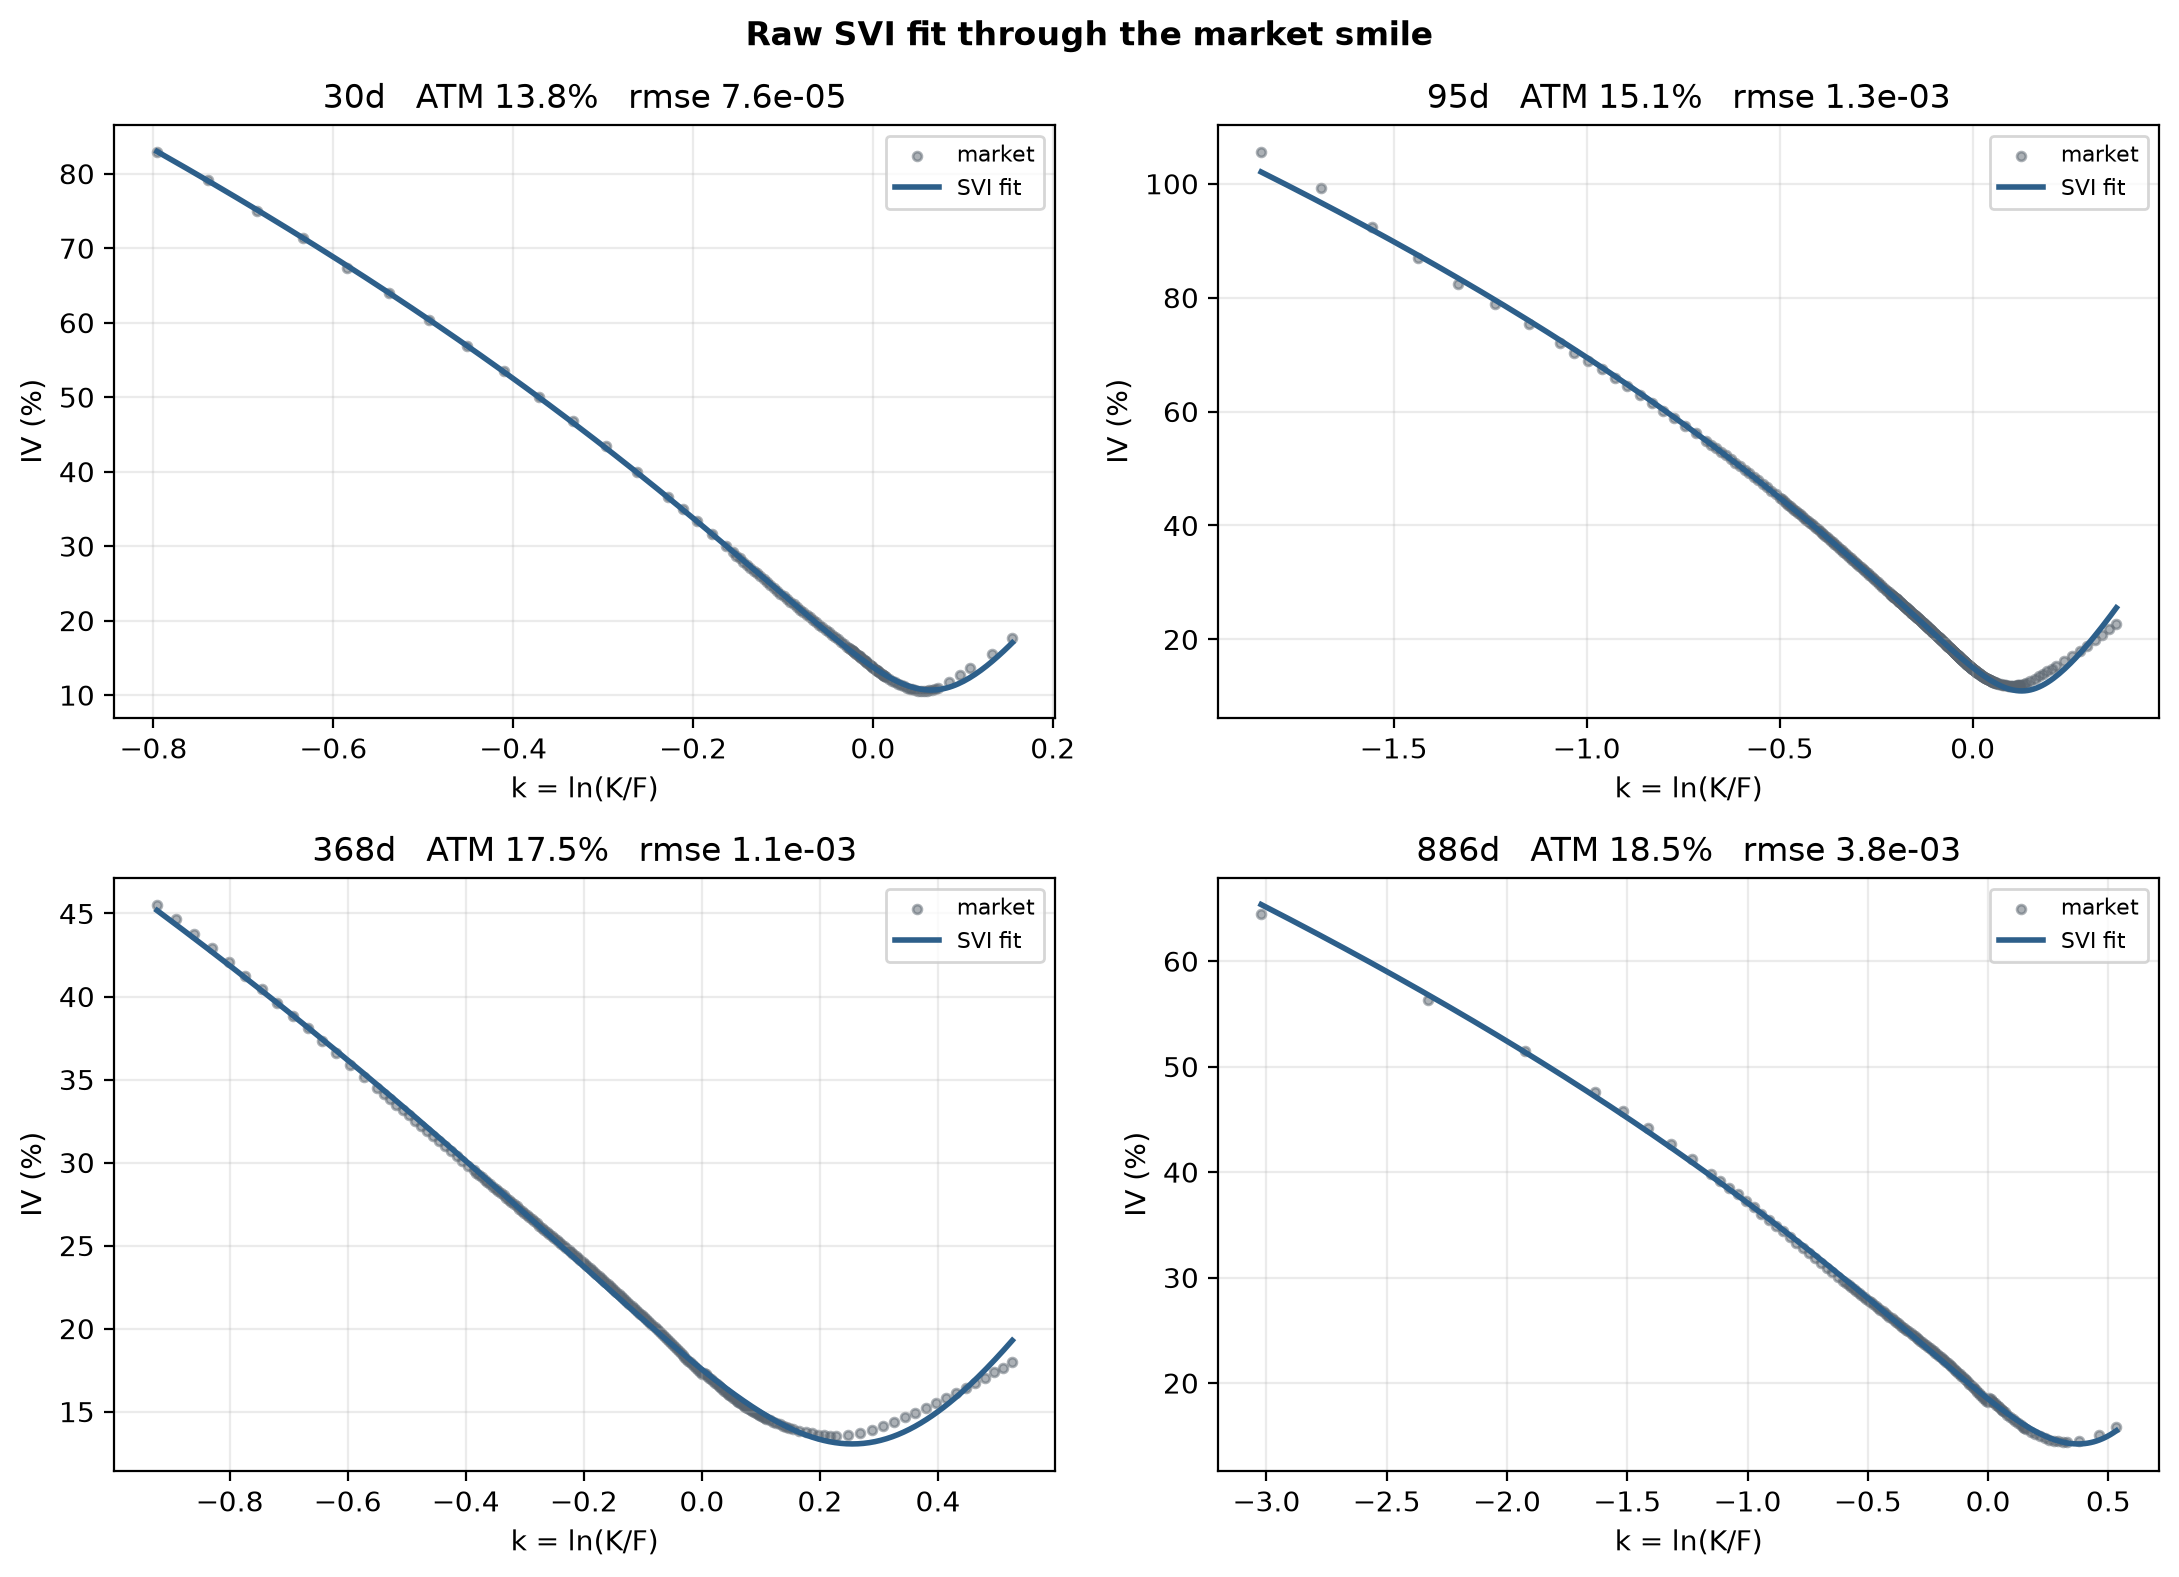

In [15]:
picks = [fit.iloc[(fit["T"]*365 - d).abs().argmin()] for d in (30, 90, 365, 1000)]
f, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, r in zip(axes.ravel(), picks):
    g = df[df.expiry == r.expiry]
    kk = np.linspace(g.k.min(), g.k.max(), 300)
    ax.scatter(g.k, g.iv*100, s=10, color=DOT, alpha=0.5, label="market")
    ax.plot(kk, slice_iv(r, kk)*100, color=CURVE, lw=2, label="SVI fit")
    ax.set_title(f"{r['T']*365:.0f}d   ATM {np.sqrt(r.theta/r['T'])*100:.1f}%   rmse {r.rmse:.1e}")
    ax.set_xlabel("k = ln(K/F)"); ax.set_ylabel("IV (%)"); ax.grid(alpha=.25); ax.legend(fontsize=8)
f.suptitle("Raw SVI fit through the market smile", fontweight="bold"); f.tight_layout()

## No-arbitrage checks

**Butterfly** (within a slice): `g(k) >= 0` everywhere ⟺ no negative implied density.
**Calendar** (across slices): ATM total variance `theta_T` must not decrease with maturity.

In [16]:
bf = butterfly_free_fraction(fit, df)
theta = fit.dropna(subset=["theta"])["theta"].to_numpy()
print(f"butterfly-free slices  (g(k) >= 0): {bf*100:.1f}%")
print(f"calendar  theta_T monotone in T   : {bool(np.all(np.diff(theta) >= 0))}"
      f"  ({int((np.diff(theta) < 0).sum())} non-monotone steps)")

butterfly-free slices  (g(k) >= 0): 98.2%
calendar  theta_T monotone in T   : True  (0 non-monotone steps)


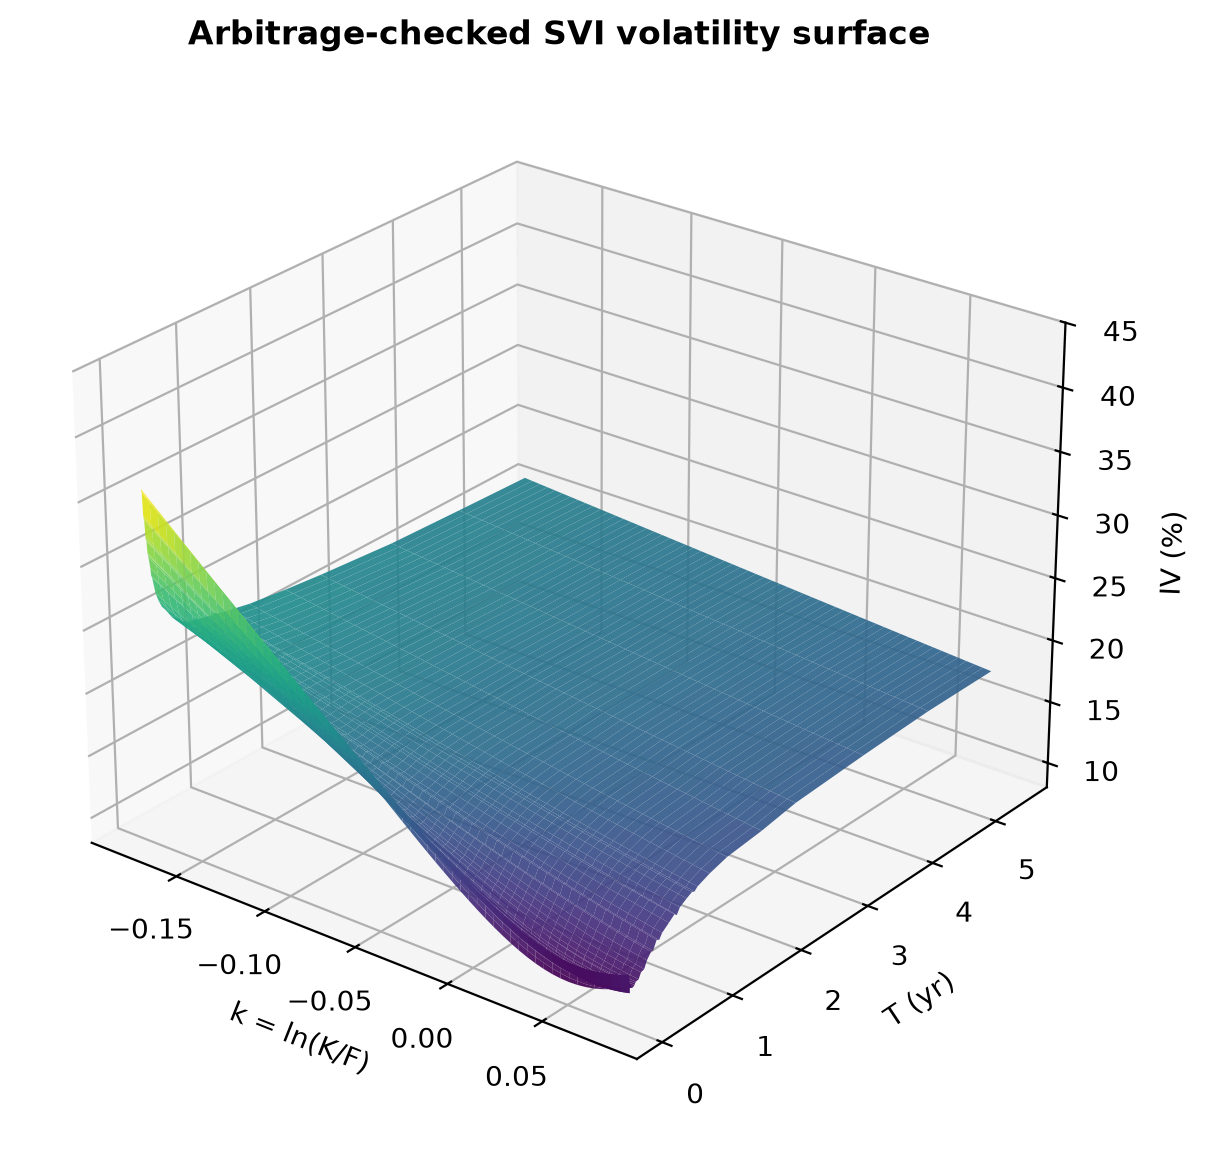

In [17]:
# 3D surface — near-money band, >= ~2wk so short-dated wings don't dominate the axis
KLO, KHI = -0.18, 0.08
srf = fit.dropna(subset=["a"])
srf = srf[srf["T"] >= 0.04]
kg = np.linspace(KLO, KHI, 60)
K, T = np.meshgrid(kg, srf["T"].to_numpy())
Z = np.array([slice_iv(r, kg)*100 for _, r in srf.iterrows()])

f = plt.figure(figsize=(10, 7)); ax = f.add_subplot(111, projection="3d")
ax.plot_surface(K, T, Z, cmap=cm.viridis, alpha=.92, linewidth=0, rcount=60, ccount=60)
ax.set_xlabel("k = ln(K/F)"); ax.set_ylabel("T (yr)"); ax.set_zlabel("IV (%)"); ax.set_zlim(8, 45)
ax.set_title("Arbitrage-checked SVI volatility surface", fontweight="bold")
ax.view_init(elev=26, azim=-52)

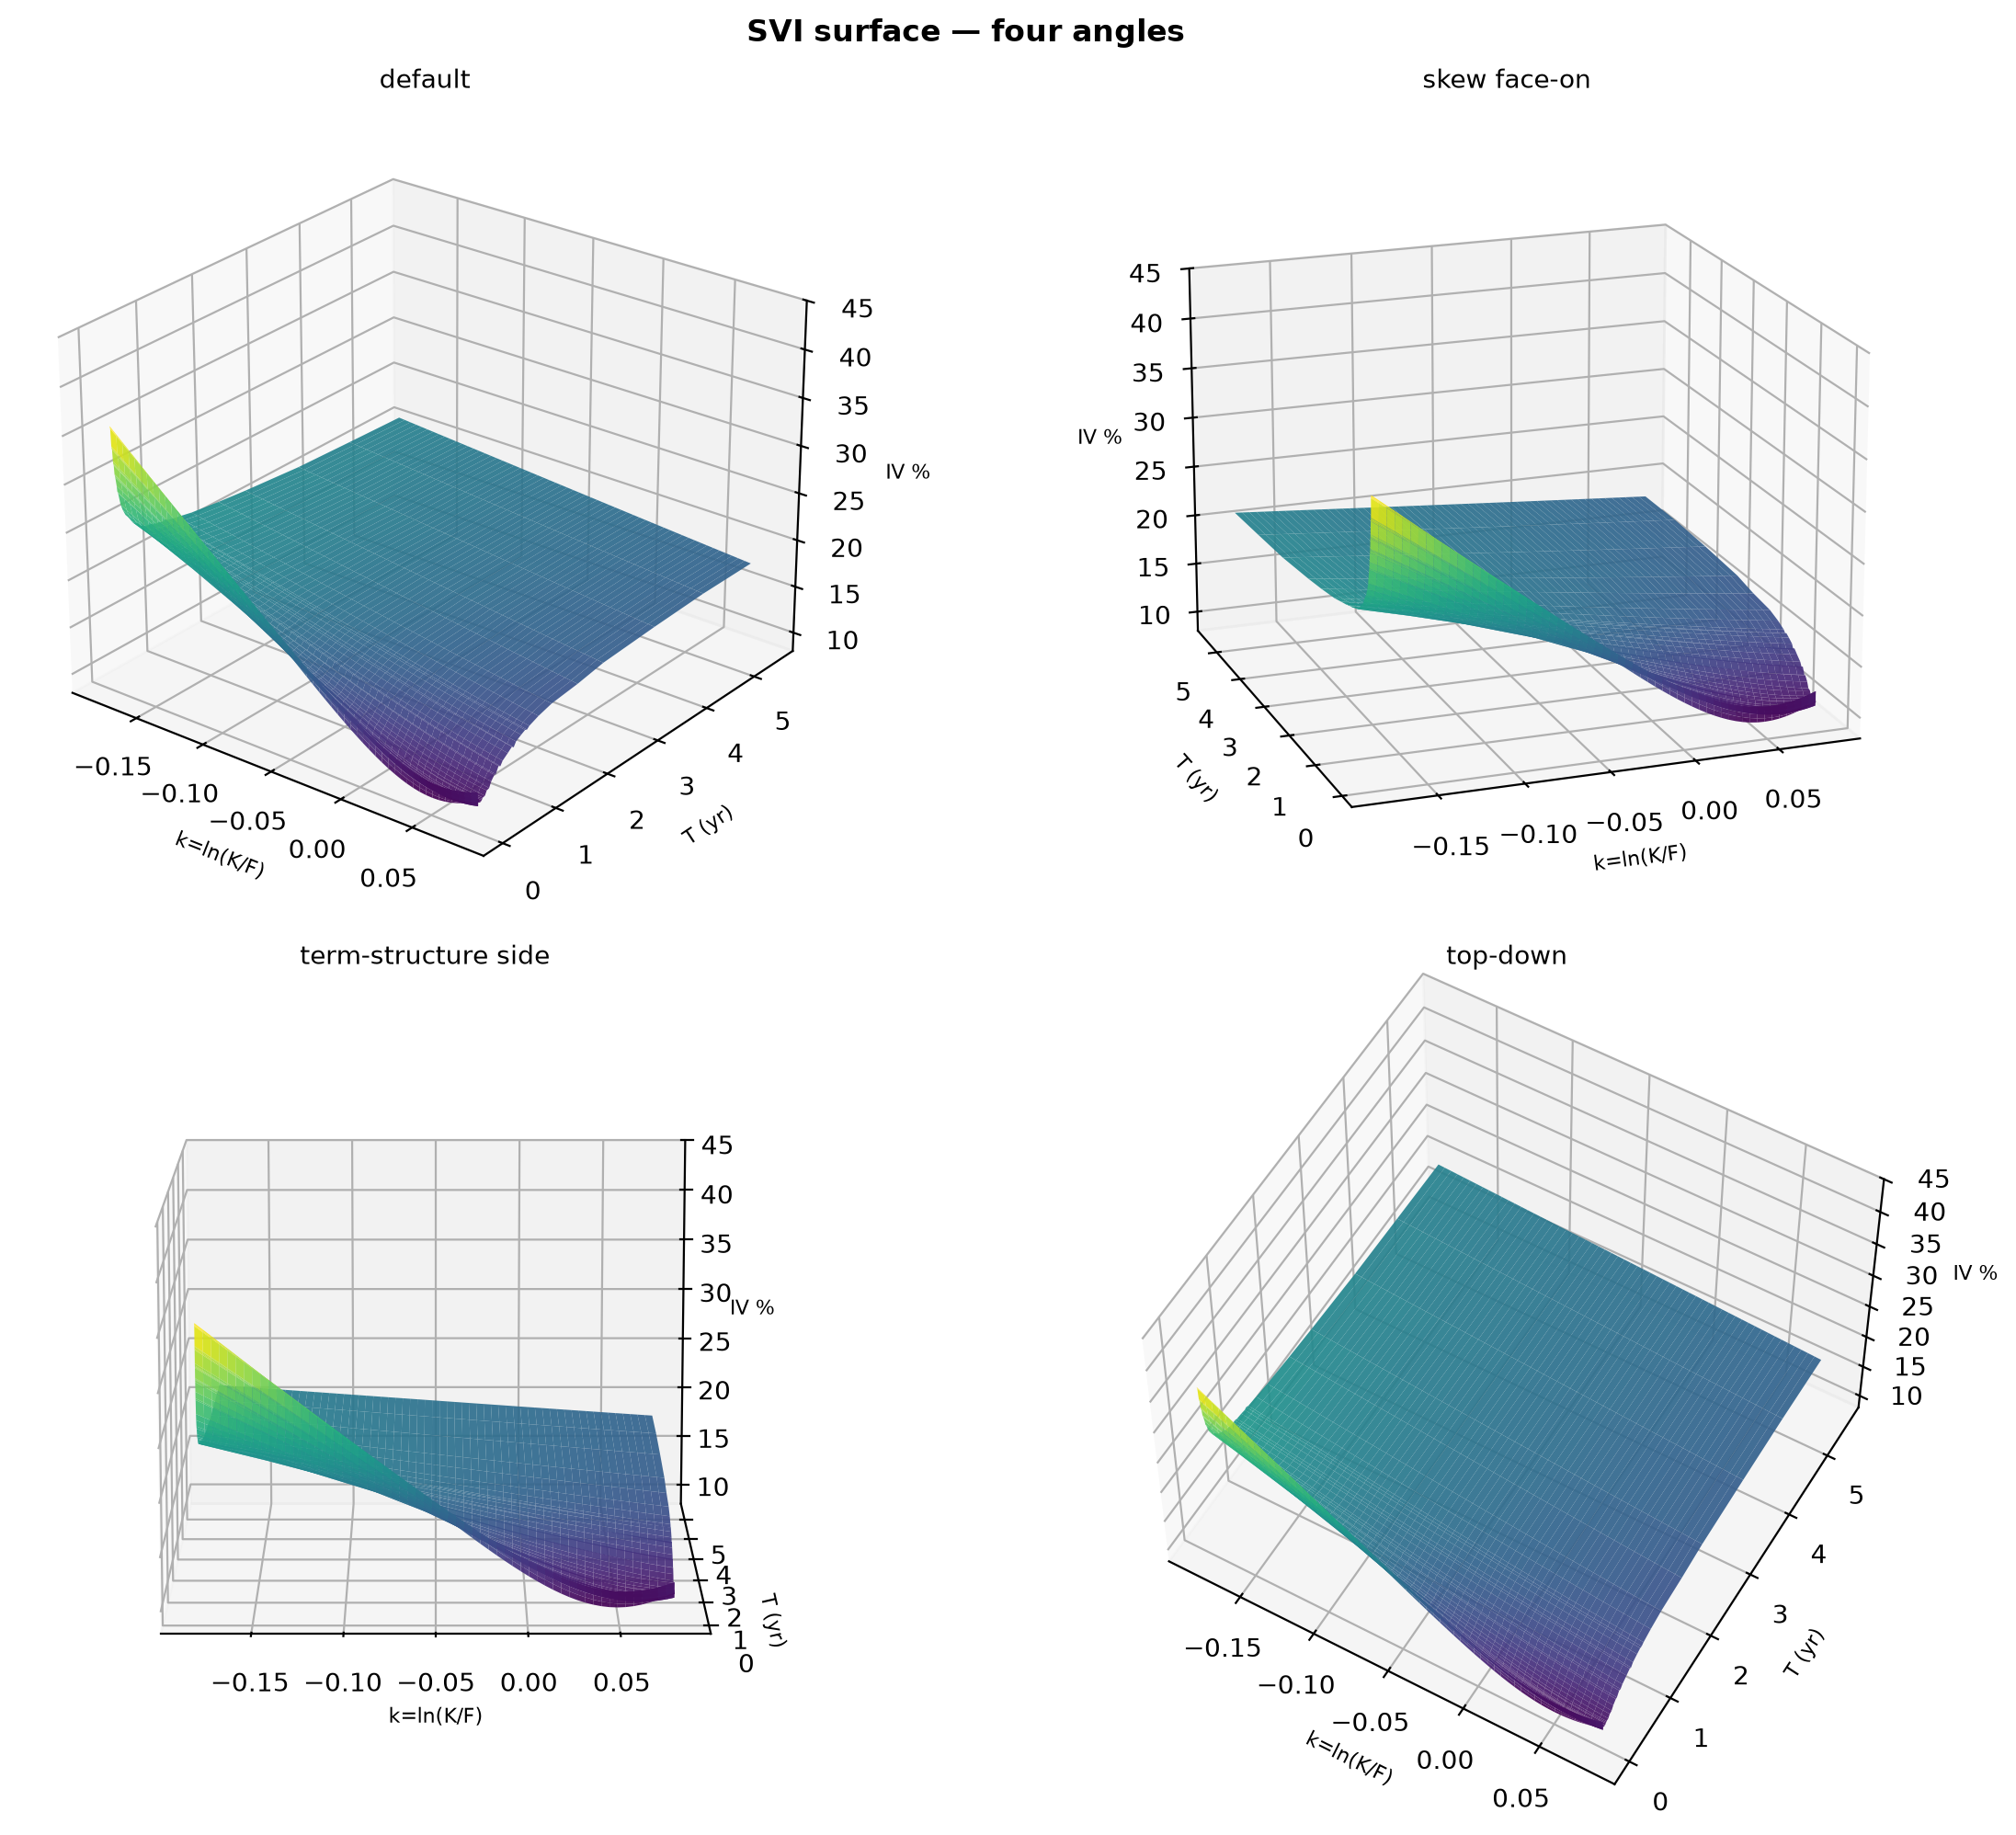

In [18]:
# same surface from four angles (skew ridge + term structure read differently per view)
views = [(26, -52, "default"), (18, -110, "skew face-on"),
         (12, -90, "term-structure side"), (55, -60, "top-down")]
f = plt.figure(figsize=(13, 10))
for i, (elev, azim, name) in enumerate(views, 1):
    ax = f.add_subplot(2, 2, i, projection="3d")
    ax.plot_surface(K, T, Z, cmap=cm.viridis, alpha=.92, linewidth=0, rcount=60, ccount=60)
    ax.set_xlabel("k=ln(K/F)", fontsize=8); ax.set_ylabel("T (yr)", fontsize=8); ax.set_zlabel("IV %", fontsize=8)
    ax.set_zlim(8, 45); ax.view_init(elev=elev, azim=azim); ax.set_title(f"{name}", fontsize=10)
f.suptitle("SVI surface — four angles", fontweight="bold"); f.tight_layout()

## Term-structure metrics

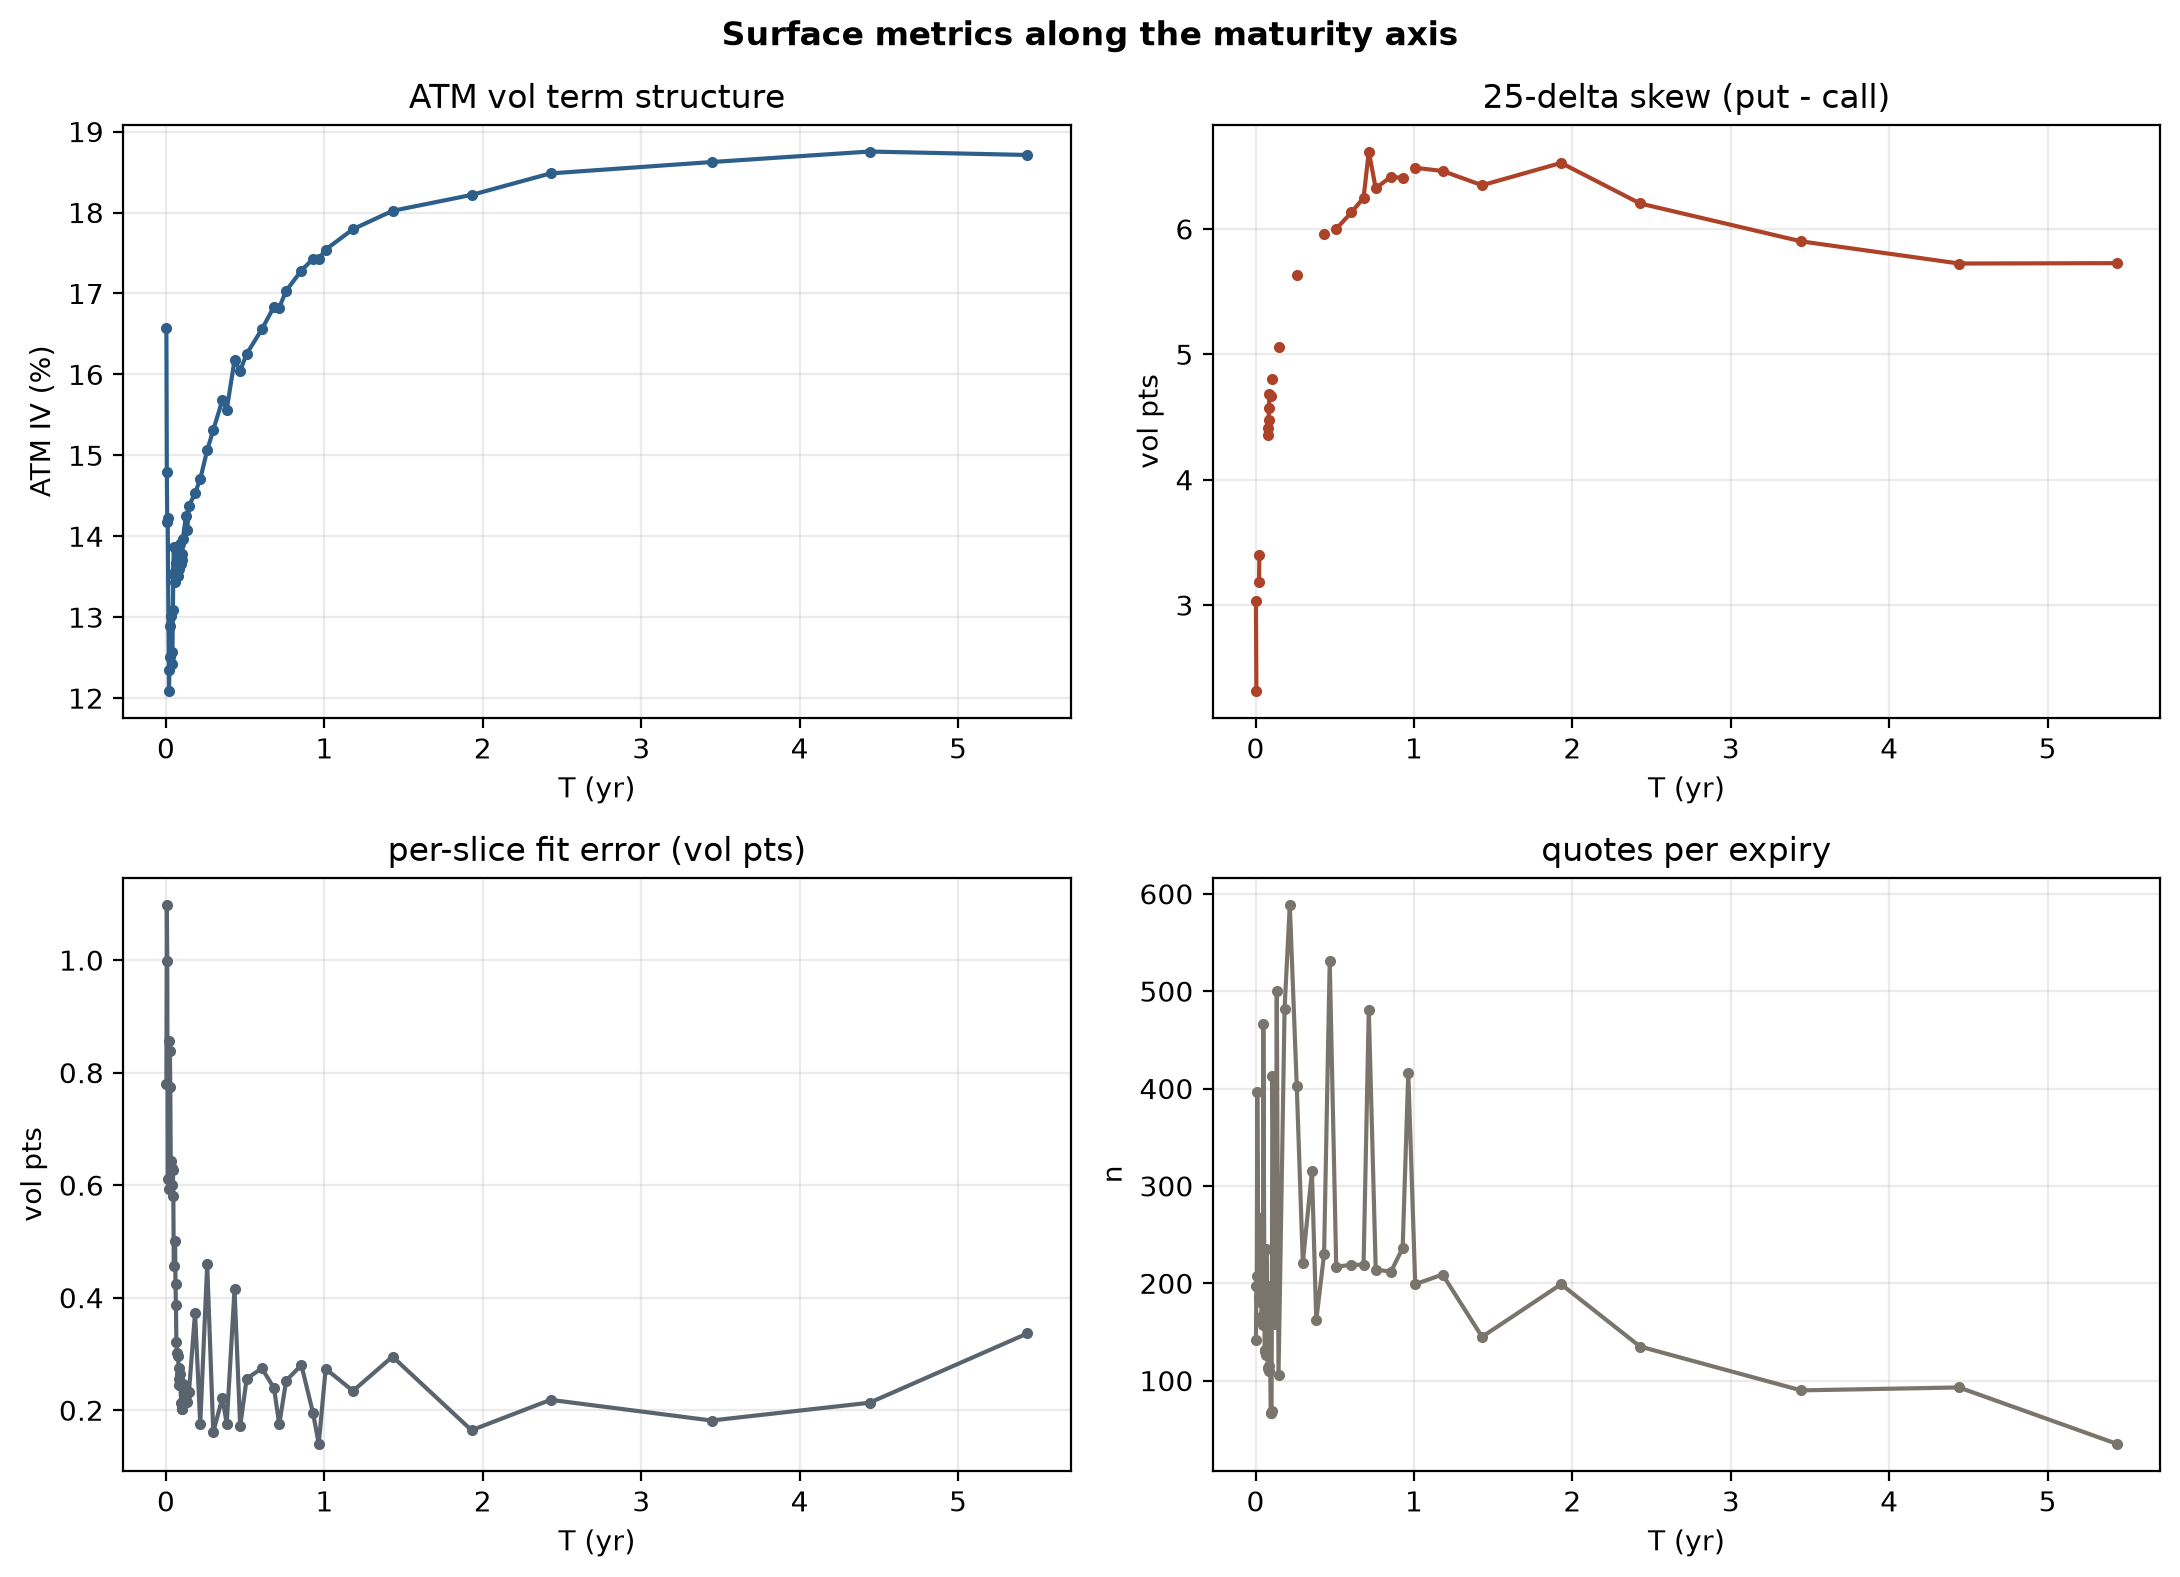

In [19]:
f, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0,0].plot(met["T"], met.atm_vol*100, "o-", color=CURVE, ms=3); ax[0,0].set_title("ATM vol term structure"); ax[0,0].set_ylabel("ATM IV (%)")
ax[0,1].plot(met["T"], met.skew_25d*100, "o-", color=WARN, ms=3); ax[0,1].set_title("25-delta skew (put - call)"); ax[0,1].set_ylabel("vol pts")
ax[1,0].plot(met["T"], met.rmse_vol*100, "o-", color=DOT, ms=3); ax[1,0].set_title("per-slice fit error (vol pts)"); ax[1,0].set_ylabel("vol pts")
ax[1,1].plot(fit["T"], fit.n_quotes, "o-", color="#7A756C", ms=3); ax[1,1].set_title("quotes per expiry"); ax[1,1].set_ylabel("n")
for a in ax.ravel(): a.grid(alpha=.25); a.set_xlabel("T (yr)")
f.suptitle("Surface metrics along the maturity axis", fontweight="bold"); f.tight_layout()

## Forward-vol event radar

Spot IV averages from *now* to each expiry, so it smears events. **Forward vol** — the vol
priced for the *future* window between two adjacent expiries, `sqrt((theta2-theta1)/(T2-T1))` —
isolates them: a window spiking above its neighbours is pricing a scheduled event (Fed, CPI).
On this calm snapshot it's flat (the dips are weekends spreading variance over 3 days).

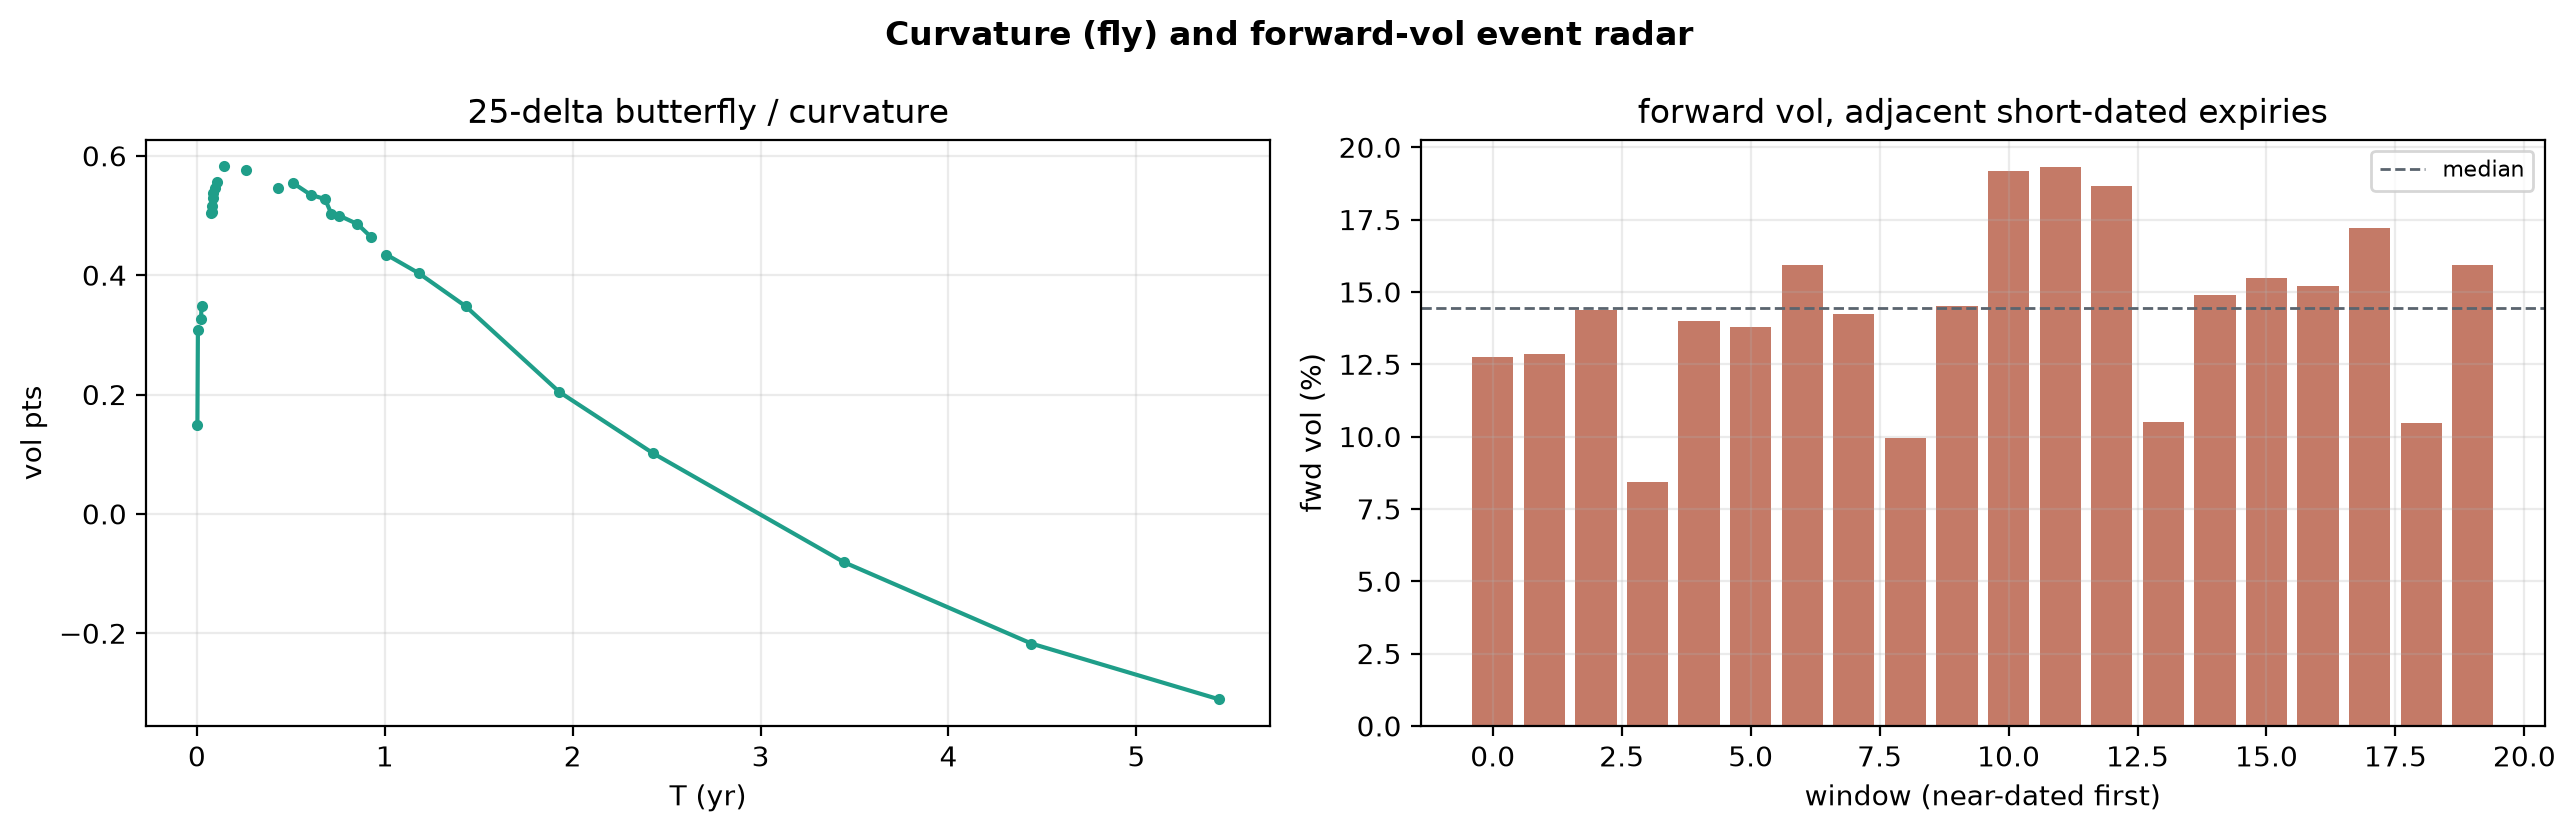

In [20]:
fv = forward_vol(fit)
f, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(met["T"], met.fly_25d*100, "o-", color=GREEN, ms=3)
ax[0].set_title("25-delta butterfly / curvature"); ax[0].set_xlabel("T (yr)"); ax[0].set_ylabel("vol pts"); ax[0].grid(alpha=.25)
ax[1].bar(range(len(fv.head(20))), fv.head(20).fwd_vol*100, color=WARN, alpha=.7)
ax[1].axhline(fv.head(20).fwd_vol.median()*100, color=DOT, ls="--", lw=1, label="median")
ax[1].set_title("forward vol, adjacent short-dated expiries"); ax[1].set_ylabel("fwd vol (%)")
ax[1].set_xlabel("window (near-dated first)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.25)
f.suptitle("Curvature (fly) and forward-vol event radar", fontweight="bold"); f.tight_layout()

## Global SSVI — provably arbitrage-free

One surface from three global params `(rho, eta, gamma)` plus the `theta_T` term structure,
fit under the Gatheral-Jacquier butterfly constraints (Thm 4.2). `theta_T` is forced
non-decreasing for calendar no-arb. Trades some fit accuracy vs per-slice SVI for a
*guaranteed* arb-free surface — the standard production tradeoff.

In [21]:
tmap = fit.dropna(subset=["theta"]).set_index("expiry")["theta"]
tmap = pd.Series(np.maximum.accumulate(tmap.to_numpy()), index=tmap.index)  # enforce monotone theta_T
q_ss = df[df.expiry.isin(tmap.index)].copy()
q_ss["theta"] = q_ss.expiry.map(tmap)

ss = fit_ssvi(q_ss, weight_col="weights")
print(f"SSVI:  rho={ss['rho']:.3f}  eta={ss['eta']:.3f}  gamma={ss['gamma']:.3f}")
print(f"butterfly_ok = {ss['butterfly_ok']}   calendar monotone = {bool(np.all(np.diff(tmap.to_numpy()) >= 0))}")
print(f"w-space rmse {ss['rmse']:.2e}   (per-slice SVI median {fit['rmse'].median():.2e})")

SSVI:  rho=-0.537  eta=1.143  gamma=0.536
butterfly_ok = True   calendar monotone = True
w-space rmse 1.21e-02   (per-slice SVI median 1.35e-04)


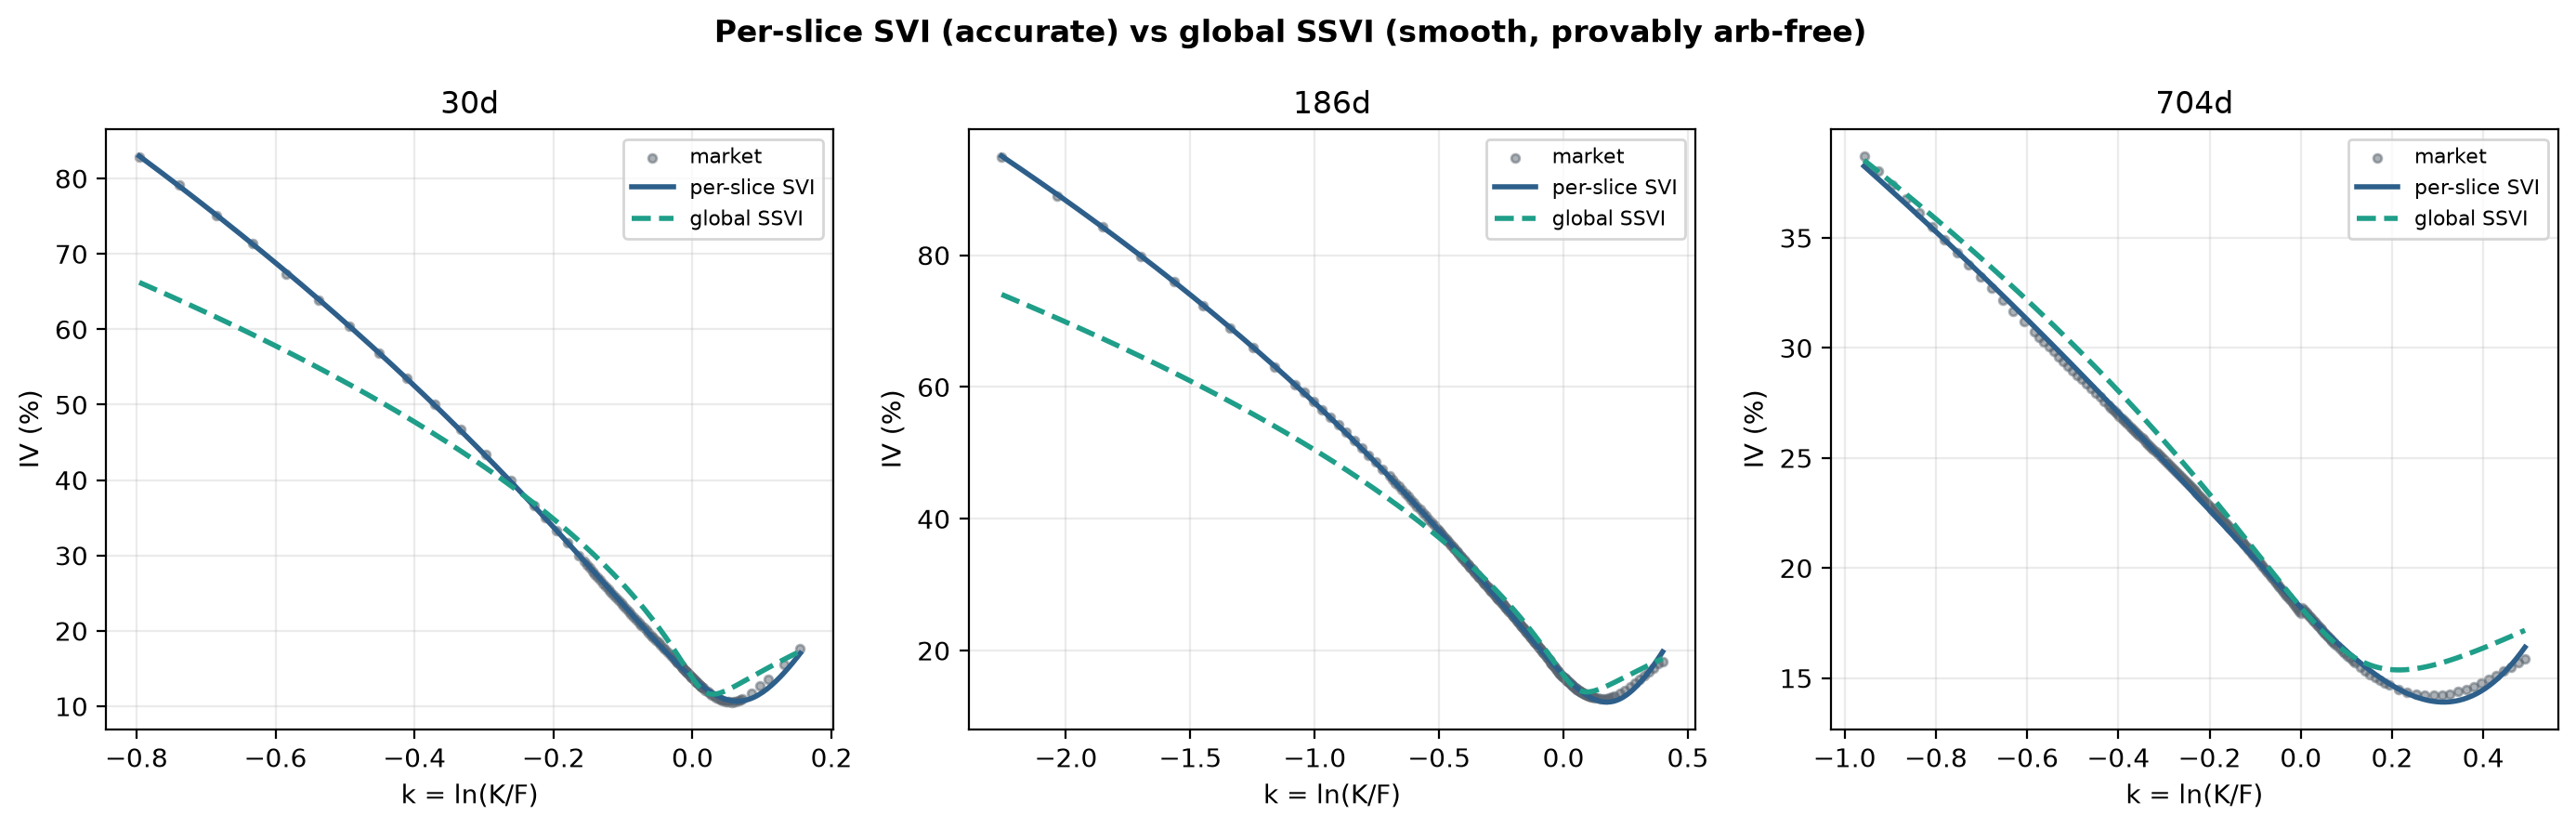

In [22]:
f, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, d in zip(axes, (30, 180, 730)):
    r = srf.iloc[(srf["T"]*365 - d).abs().argmin()]
    g = df[df.expiry == r.expiry]; kk = np.linspace(g.k.min(), g.k.max(), 300)
    ax.scatter(g.k, g.iv*100, s=10, color=DOT, alpha=.5, label="market")
    ax.plot(kk, slice_iv(r, kk)*100, color=CURVE, lw=2, label="per-slice SVI")
    iv_ss = np.sqrt(np.maximum(ssvi_w(kk, tmap[r.expiry], ss['rho'], ss['eta'], ss['gamma']), 1e-9) / r["T"])
    ax.plot(kk, iv_ss*100, color=GREEN, lw=2, ls="--", label="global SSVI")
    ax.set_title(f"{r['T']*365:.0f}d"); ax.set_xlabel("k = ln(K/F)"); ax.set_ylabel("IV (%)"); ax.grid(alpha=.25); ax.legend(fontsize=8)
f.suptitle("Per-slice SVI (accurate) vs global SSVI (smooth, provably arb-free)", fontweight="bold"); f.tight_layout()

## Summary

| | value |
|---|---|
| clean OTM quotes | ~12,100 across 55 expiries (1–1985 d) |
| raw SVI fit | 55/55 expiries; ~0.27 vol-pt median all-in, but **~0.15 vp near-money on 30d–2y (≈ bid-ask floor)** — the sub-week smile (~0.9 vp) and deep wings drive the tail |
| butterfly-free slices | ~98% (`g(k) >= 0`) |
| calendar | `theta_T` monotone in T |
| SSVI | arb-free by construction; ~1 vol-pt median cost vs per-slice |
| 30d ATM vol / 25d skew | ~13.8% / ~4.5 vol pts |
| ATM term structure | ~12% → ~19% (contango); skew hump ~1–2y |

*Numbers regenerate on run; commit the rendered outputs. The sub-week looseness is expected — w-space fitting amplifies small-T errors in vol space, and SVI's smooth form fights the near-expiry (0DTE) kink; that region is typically modeled separately.*